# BrushCue Example: Static Noise

<a href="https://colab.research.google.com/github/ditotechnologies/brushcue/blob/main/examples/static_noise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

You can use this tool online at https://www.brushcue.com/tools/static-noise

In [ ]:
!pip install brushcue

[wgpu] using backend Metal — adapter 'Apple M5' (IntegratedGpu), driver ''


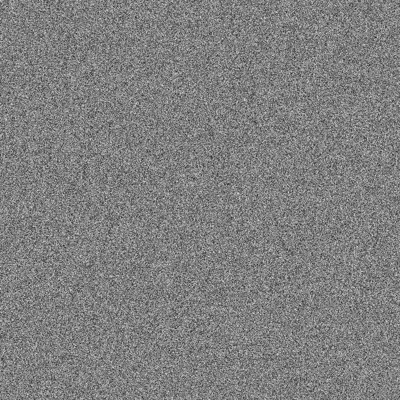

In [1]:
import io
from PIL import Image

import brushcue as bc

width = 1024
height = 1024
seed = 1.0
graph = bc.Composition.freeform_shader(
    "let pixel = vec2<u32>(canvas_position);\nvar hash = pixel.x * 374761393u + pixel.y * 668265263u + u32(seed) * 2246822519u;\nhash = (hash ^ (hash >> 13u)) * 1274126177u;\nhash = hash ^ (hash >> 16u);\nlet noise = f32(hash & 0x00ffffffu) / 16777215.0;\nreturn vec4<f32>(noise, noise, noise, 1.0);",
    "",
    bc.Bounds2f.from_x_y_width_height(
        0.0, 0.0, bc.Int.to_float(width), bc.Int.to_float(height)
    ),
    bc.ColorRepresentation.srgb(),
    bc.Dictionary.create().add("seed", seed),
)

ctx = bc.Context()
composition = graph.execute(ctx)
data_bytes = composition.to_image_bytes(ctx)
img = Image.open(io.BytesIO(data_bytes))
img.thumbnail((400, 400))  # Remove this line for full resolution
img
